<a href="https://colab.research.google.com/github/mzabala2006-beep/Reconocimiento_de_emociones_FER2013/blob/main/Examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras import layers, models



In [2]:
from google.colab import files
uploaded = files.upload()

Saving FER2013.zip to FER2013.zip


In [3]:
zip_path = "FER2013.zip"
extract_path = "/content/FER2013"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
train_generator = datagen.flow_from_directory(
    "/content/FER2013/train",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical"
)

test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    "/content/FER2013/test",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical"
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [5]:
num_classes = train_generator.num_classes

model = models.Sequential([
    layers.Input(shape=(48,48,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5632 - loss: 1.1650 - val_accuracy: 0.5986 - val_loss: 1.0742
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5602 - loss: 1.1648 - val_accuracy: 0.5878 - val_loss: 1.0833
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5624 - loss: 1.1627 - val_accuracy: 0.6006 - val_loss: 1.0686
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5663 - loss: 1.1565 - val_accuracy: 0.5872 - val_loss: 1.0952
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5652 - loss: 1.1632 - val_accuracy: 0.5953 - val_loss: 1.0700
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.5590 - loss: 1.1656 - val_accuracy: 0.5876 - val_loss: 1.0839
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.5604 - loss: 1.1596 - val_accuracy: 0.5843 - val_loss: 1.0937
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.5659 - loss: 1.1524 - 

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6119 - loss: 1.0361
Loss en test: 1.0361
Accuracy en test: 61.19%


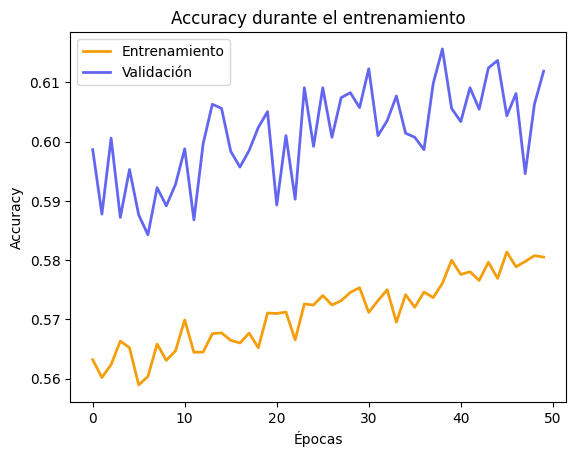

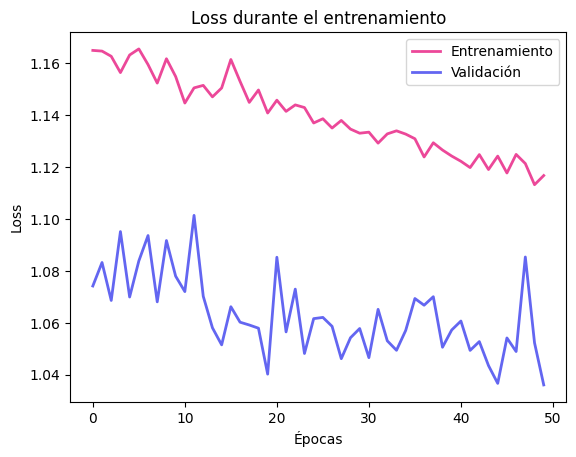

In [21]:
loss, accuracy = model.evaluate(test_generator, verbose=1)
print(f"Loss en test: {loss:.4f}")
print(f"Accuracy en test: {accuracy*100:.2f}%")

plt.plot(history.history['accuracy'], label='Entrenamiento', color='#F59E0B', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validación',color='#6366F1', linewidth=2)
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Entrenamiento', color='#EC4899', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación',color='#6366F1', linewidth=2)
plt.title("Loss durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

Found 3995 images belonging to 1 classes.


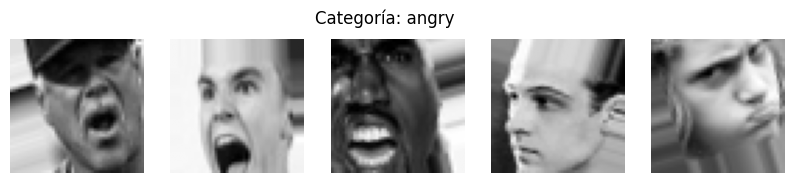

Found 436 images belonging to 1 classes.


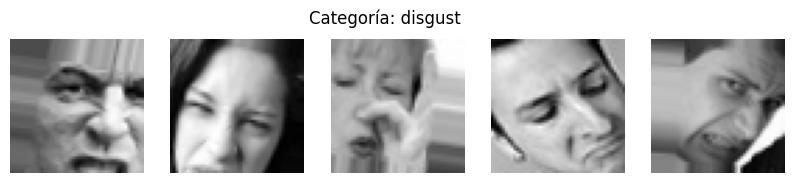

Found 4097 images belonging to 1 classes.


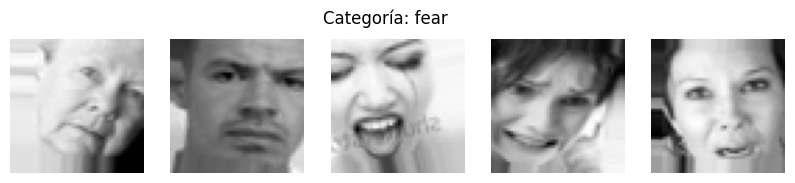

Found 7215 images belonging to 1 classes.


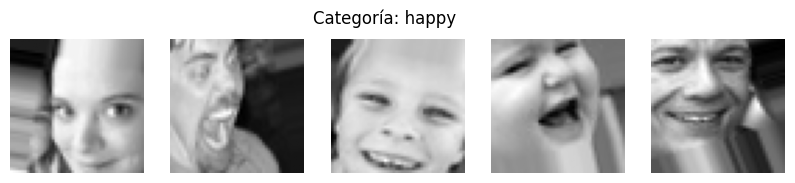

Found 4965 images belonging to 1 classes.


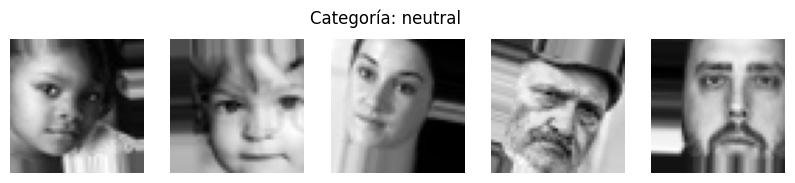

Found 4830 images belonging to 1 classes.


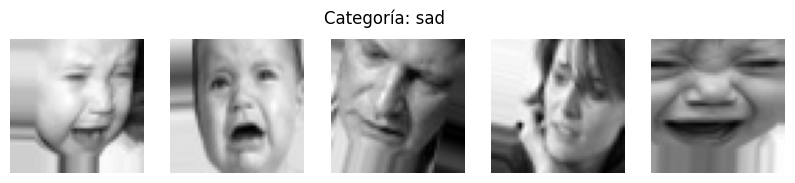

Found 3171 images belonging to 1 classes.


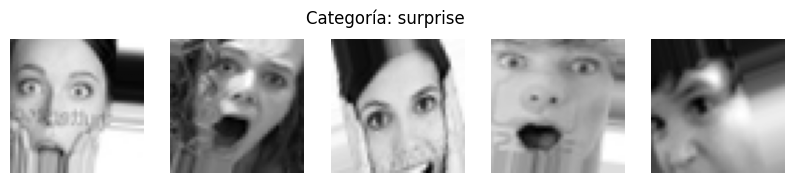

In [22]:
class_names = list(train_generator.class_indices.keys())

# Mostrar 5 imágenes de cada clase
for class_name in class_names:

    temp_gen = datagen.flow_from_directory(
        "/content/FER2013/train",
        target_size=(48,48),
        color_mode="grayscale",
        batch_size=5,
        classes=[class_name],
        class_mode="categorical",
        shuffle=True
    )

    images, labels = next(temp_gen)

    plt.figure(figsize=(10,2))
    for i in range(5):
        plt.subplot(1,5,i+1)
        plt.imshow(images[i].reshape(48,48), cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Categoría: {class_name}")
    plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


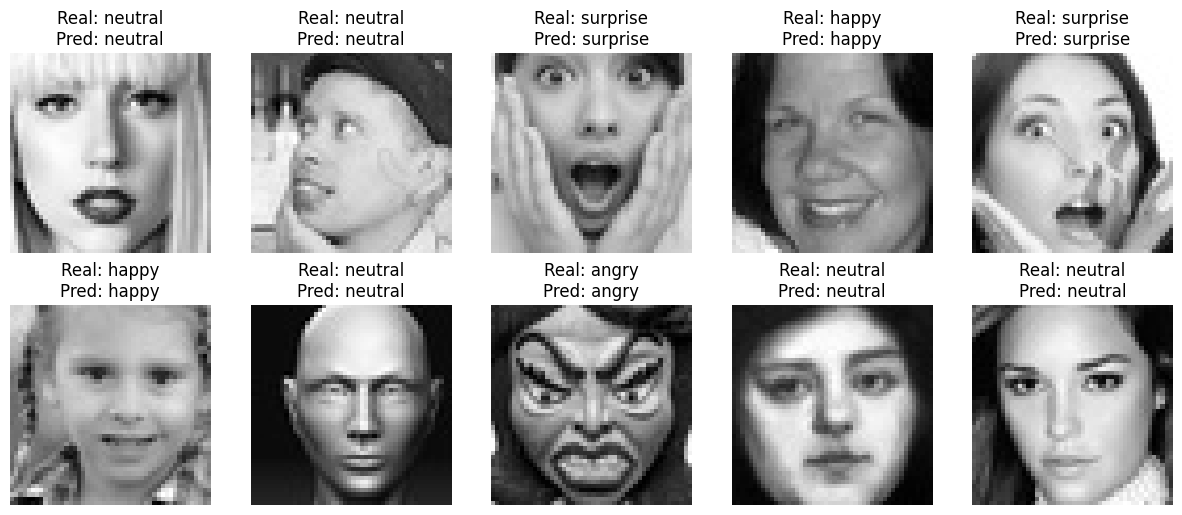

In [23]:
import numpy as np
import matplotlib.pyplot as plt

class_names = list(test_generator.class_indices.keys())

images, labels = next(test_generator)

predictions = model.predict(images)

# Mostrar las primeras 10 imágenes con etiqueta real y predicción
plt.figure(figsize=(15,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].reshape(48,48), cmap="gray")
    plt.axis("off")

    real_class = class_names[np.argmax(labels[i])]
    pred_class = class_names[np.argmax(predictions[i])]

    plt.title(f"Real: {real_class}\nPred: {pred_class}")
plt.show()


In [24]:
loss_final, accuracy_final = model.evaluate(test_generator, verbose=0)

print("Resultados en datos de prueba (FER2013):")
print(f"   Loss (error):  {loss_final:.4f}")
print(f"   Accuracy:      {accuracy_final*100:.2f}%")
print(f"   Imágenes bien clasificadas: {int(accuracy_final * test_generator.samples)} de {test_generator.samples}")


Resultados en datos de prueba (FER2013):
   Loss (error):  1.0361
   Accuracy:      61.19%
   Imágenes bien clasificadas: 4391 de 7178


In [25]:
model.save("modelo_final.keras")


In [30]:
!pip install tensorflow opencv-python numpy

